# sde_model.ipynb

Initial model for the governing SDE. Keep in mind layers are low, since this is a "hackathon" project.

### Initial instructions

- Make sure to have a ```.venv``` set up. Install ```torch```, ```torchsde```, ```numpy```, ```matplotlib```. 

#### Package imports

In [ ]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np

Priority: mps (Apple Silicon) > CUDA > CPU

In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


#### Synthetic data generation (just in case)

In [6]:
def generate_synthetic_flight(num_steps=100):
    t = torch.linspace(0, 1, num_steps).to(device)
    # Synthetic ground truth: Linear fuel burn, constant velocity, slight climb
    # Shape: [Time, 3] -> [Fuel, Velocity, Altitude]
    fuel = 1.0 - 0.2 * t 
    velocity = 0.8 + 0.05 * torch.sin(5 * t)
    altitude = 0.5 + 0.3 * t
    
    y_true = torch.stack([fuel, velocity, altitude], dim=-1).unsqueeze(1) # [T, Batch=1, 3]
    return t, y_true

#### NeuralSDE class

In [7]:
class NeuralSDE(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        # Input: [Fuel, Velocity, Altitude]
        self.input_dim = 3
        
        # Drift (deterministic)
        self.f_net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.ELU(), # ELU is often smoother for SDEs than ReLU
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, 3)
        )
        
        # Diffusion (stochastic)
        self.g_net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),
            nn.Softplus() # Standard dev must be positive
        )
        
        self.noise_type = "diagonal"
        self.sde_type = "ito"

    def f(self, t, y):
        # y shape: [batch_size, 3]
        return self.f_net(y)

    def g(self, t, y):
        # y shape: [batch_size, 3]
        return self.g_net(y)

#### Training

In [ ]:
def train_step(model, batch_y0, batch_t, batch_y_true, optimizer, is_lbfgs=False):
    model.train()

    def closure():
        optimizer.zero_grad()    
        """
        Integrate the SDE
        # batch_y0: Initial state [Fuel, Altitude]
        # batch_t: Time steps for the flight duration
        """
        pred_y = torchsde.sdeint_adjoint(model, batch_y0, batch_t, dt=0.1, method='euler')
    
        """Loss Function 
        MSE for trajectories
        """
        loss = nn.MSELoss()(pred_y, batch_y_true)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Bound the trajectory, planes don't work in outer space.
        return loss
    
    if is_lbfgs:
        loss = optimizer.step(closure)
    else:
        loss = closure()
        optimizer.step()
    
    return loss.item()


def train_model(model, t, y_true, epochs=500, lbfgs_start_epoch=450):
    # 1. Initialize Optimizers
    # AdamW for the bulk of training
    optimizer_adam = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

    
    # LBFGS for fine-tuning
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(), 
        lr=0.1, 
        max_iter=20, 
        history_size=10, 
        line_search_fn="strong_wolfe"
    )
    
    """
    Optimizer selection:
    - We use AdamW as a way to begin our training, and to carry us through most of the iterations
    - We later refine using LBFGS, which will take more into account the actual geometry (second order derivatives) of the problem
    """

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, 'min', patience=5, factor=0.5) # If our loss doesn't improve in 5 epochs, we cut the learning rate
    
    # Ensure data is on the correct device
    y0 = y_true[0].to(device)
    t = t.to(device)
    y_true = y_true.to(device)

    for epoch in range(1, epochs + 1):
        model.train()

        if epoch < lbfgs_start_epoch:
            "AdamW step"
            loss = train_step(model, y0, t, y_true, optimizer_adam)
        else:
            "LBFGS step"
            loss = train_step(model, y0, t, y_true, optimizer_lbfgs, True)
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {loss:.6f} | Mode: {'AdamW' if epoch < lbfgs_start_epoch else 'LBFGS'}")

    return model

#### Actually running the code

In [15]:
model = NeuralSDE().to(device)
t, y_true = generate_synthetic_flight()
y0 = y_true[0]
train_model(model, t, y_true)

Epoch 001 | Loss: 0.272034 | Mode: AdamW
Epoch 020 | Loss: 0.197566 | Mode: AdamW
Epoch 040 | Loss: 0.040983 | Mode: AdamW
Epoch 060 | Loss: 0.015093 | Mode: AdamW
Epoch 080 | Loss: 0.019306 | Mode: AdamW
Epoch 100 | Loss: 0.017056 | Mode: AdamW
Epoch 120 | Loss: 0.005862 | Mode: AdamW
Epoch 140 | Loss: 0.001987 | Mode: AdamW
Epoch 160 | Loss: 0.004768 | Mode: AdamW
Epoch 180 | Loss: 0.003088 | Mode: AdamW
Epoch 200 | Loss: 0.007017 | Mode: AdamW
Epoch 220 | Loss: 0.006651 | Mode: AdamW
Epoch 240 | Loss: 0.002676 | Mode: AdamW
Epoch 260 | Loss: 0.003747 | Mode: AdamW
Epoch 280 | Loss: 0.002914 | Mode: AdamW
Epoch 300 | Loss: 0.000720 | Mode: AdamW
Epoch 320 | Loss: 0.000383 | Mode: AdamW
Epoch 340 | Loss: 0.000925 | Mode: AdamW
Epoch 360 | Loss: 0.001971 | Mode: AdamW
Epoch 380 | Loss: 0.002326 | Mode: AdamW
Epoch 400 | Loss: 0.003365 | Mode: AdamW
Epoch 420 | Loss: 0.001079 | Mode: AdamW
Epoch 440 | Loss: 0.002008 | Mode: AdamW
Epoch 460 | Loss: 0.001331 | Mode: LBFGS
Epoch 480 | Loss

NeuralSDE(
  (f_net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
  (g_net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=3, bias=True)
    (3): Softplus(beta=1.0, threshold=20.0)
  )
)

#### Uncertainty cone (for display)

In [16]:
def generate_uncertainty_cone(model, y0, t_span, num_simulations=100):
    model.eval()
    with torch.no_grad():
        # Repeat y0 for Monte Carlo sampling
        y0_expanded = y0.repeat(num_simulations, 1).to(device)
        t_span = t_span.to(device)
        
        # All 100 flights simulated in one GPU pass
        trajectories = torchsde.sdeint(model, y0_expanded, t_span, method='euler')
        
    return trajectories.cpu() # Move back to CPU for plotting with Matplotlib

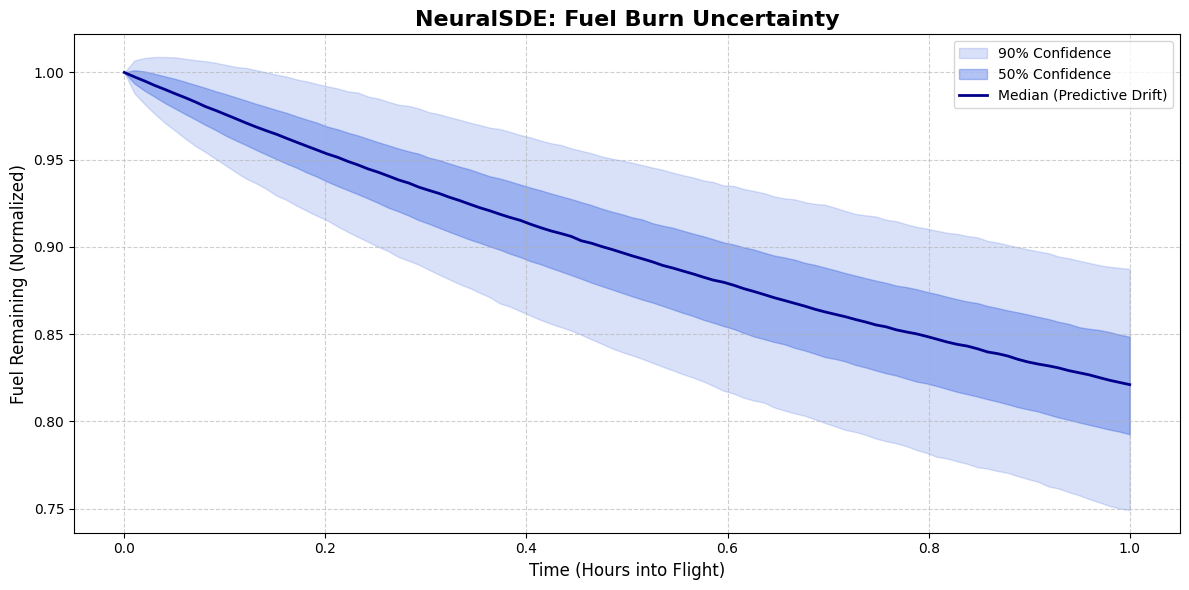

In [ ]:
def plot_fuel_fan_chart(trajectories, t_span, title="Probabilistic Fuel Consumption"):
    """
    trajectories: Tensor of shape [Time, Simulations, 3]
    t_span: Tensor of shape [Time]
    """
    # 1. Extract Fuel (Index 0) and move to CPU/Numpy
    # Shape becomes [Time, Simulations]
    fuel_data = trajectories[:, :, 0].cpu().numpy()
    t = t_span.cpu().numpy()

    # 2. Calculate Percentiles across the 'Simulations' axis (axis=1)
    median = np.median(fuel_data, axis=1)
    p5 = np.percentile(fuel_data, 5, axis=1)
    p25 = np.percentile(fuel_data, 25, axis=1)
    p75 = np.percentile(fuel_data, 75, axis=1)
    p95 = np.percentile(fuel_data, 95, axis=1)

    # 3. Plotting
    plt.figure(figsize=(12, 6), dpi=100)
    
    # Outer Band (5% - 95%): Extreme scenarios/Weather impact
    plt.fill_between(t, p5, p95, color='royalblue', alpha=0.2, label='90% Confidence')
    
    # Inner Band (25% - 75%): Likely scenarios
    plt.fill_between(t, p25, p75, color='royalblue', alpha=0.4, label='50% Confidence')
    
    # Median Line: The "Expected" path
    plt.plot(t, median, color='darkblue', lw=2, label='Median (Predictive Drift)')

    # Formatting for the Pitch Deck
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Time (Hours into Flight)", fontsize=12)
    plt.ylabel("Fuel Remaining (Normalized)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()



num_scenarios = 100 
# y0 shape is [1, 3], we want [100, 3]
y0_expanded = y_true[0].repeat(num_scenarios, 1)
# This returns a tensor of shape [Time_Steps, 100, 3]
trajectories = generate_uncertainty_cone(model, y0_expanded, t)
plot_fuel_fan_chart(trajectories, t, title="NeuralSDE: Fuel Burn Uncertainty")